In [1]:
import serial
import numpy as np
import time
from matplotlib import pyplot as plt
from ribbn_scripts.hardware_api.hardware import Exciter,Tag
import json

In [2]:
com_port1="/dev/tty.usbmodem113301"
tag1=Tag(com_port1)
ip_port_out = tag1.get_ip_port()
print(ip_port_out)
if ip_port_out['net']=='up':
    tag1.connect_wifi(ip_port_out["ip"], ip_port_out["port"])
else:
    raise Exception("Net not connected.")
print(tag1.get_mac())

com_port2="/dev/tty.usbmodem113401"
tag2=Tag(com_port2)
ip_port_out = tag2.get_ip_port()
print(ip_port_out)
if ip_port_out['net']=='up':
    tag2.connect_wifi(ip_port_out["ip"], ip_port_out["port"])
else:
    raise Exception("Net not connected.")
print(tag2.get_mac())


# com_port3="/dev/tty.usbserial-1120"
# tag3=Tag(com_port3)
# print(tag3.get_mac())


{'net': 'up', 'ip': '192.168.1.20', 'port': 3333, 'rssi': -75}
b'cmd:not found, mac\r\n'
{'net': 'up', 'ip': '192.168.1.24', 'port': 3333, 'rssi': -80}
b'cmd:not found, mac\r\n'


## ADC noise floor plotting.
Tag1

b'ch: 1, ok\r\n' 	 b'ch: 1, ok\r\n'
Voltage array len: 3312


Text(0, 0.5, 'ADC out (mV)')

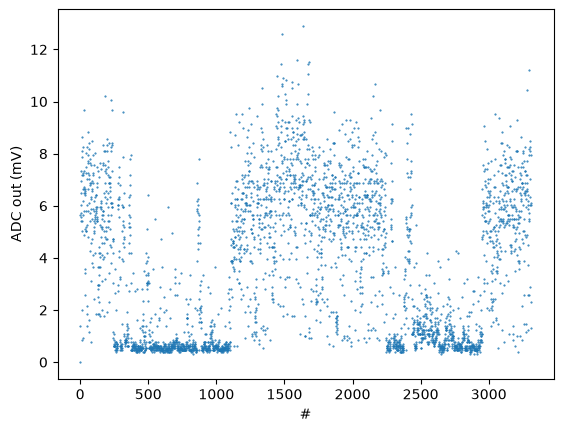

In [3]:
tag1.reflect(1)
tag1.begin_reading()
time.sleep(.2)
voltage_readings_newtag1=tag1.stop_reading()
print("Voltage array len:",len(voltage_readings_newtag1), )
plt.plot(voltage_readings_newtag1, '.',markersize=1)
plt.xlabel("#")
plt.ylabel("ADC out (mV)")

In [4]:
tag1.reflect_wifi(3)
tag1.begin_reading_wifi()
time.sleep(0.2)
voltage_readings_newtag1_wifi=tag1.stop_reading_wifi()
print("Voltage array len:",len(voltage_readings_newtag1_wifi))
plt.plot(voltage_readings_newtag1_wifi, '.', markersize=1)
plt.xlabel("#")
plt.ylabel("ADC out (mV)")

b'ch: 3, ok\r\n' 	 b'ch: 3, ok\r\n'


Exception: Stuck in stop_reading_wifi

b'ch: 3, ok\r\n' 	 b'ch: 3, ok\r\n'
Voltage array len: 3304


Text(0, 0.5, 'ADC out (mV)')

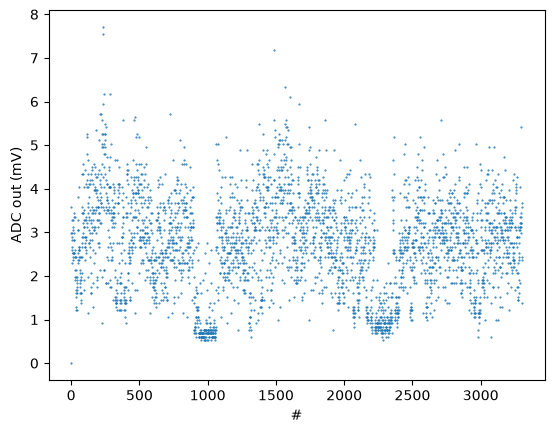

In [5]:
tag2.reflect(3)
tag2.begin_reading()
time.sleep(0.2)
voltage_readings_newtag2=tag2.stop_reading()
print("Voltage array len:",len(voltage_readings_newtag2))
plt.plot(voltage_readings_newtag2, '.', markersize=1)
plt.xlabel("#")
plt.ylabel("ADC out (mV)")

b'ch: 3, ok\r\n' 	 b'ch: 3, ok\r\n'
Voltage array len: 10000


Text(0, 0.5, 'ADC out (mV)')

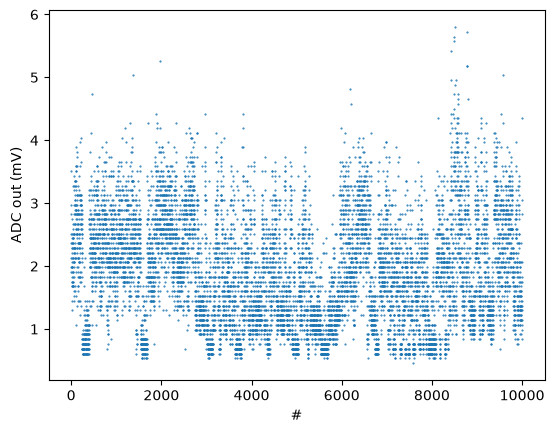

In [6]:
tag2.reflect_wifi(3)
tag2.begin_reading_wifi()
time.sleep(0.2)
voltage_readings_newtag2_wifi=tag2.stop_reading_wifi()
print("Voltage array len:",len(voltage_readings_newtag2_wifi))
plt.plot(voltage_readings_newtag2_wifi, '.', markersize=1)
plt.xlabel("#")
plt.ylabel("ADC out (mV)")

In [7]:
# tag3.reflect(1)
# tag3.begin_reading()
# time.sleep(10)
# voltage_readings_newtag3=tag3.stop_reading()
# print("Voltage array len:",len(voltage_readings_newtag3), )
# plt.plot(voltage_readings_newtag3, '.', markersize=1)
# plt.xlabel("#")
# plt.ylabel("ADC out (mV)")

In [8]:
def plotMPPs(t1, t2):
    plt.figure(figsize=(20,10))
    for rep in range(5):
        plt.subplot(2,3,rep+1)
        print("Begin reading")     
        t1.begin_reading()

        print("Starting MPP")     
        mpp_start_time,mpp_stop_time=t2.perform_mpp()

        print("Reading response")
        voltage_readings=t1.stop_reading()
        print(f"Got {len(voltage_readings)} readings.")

        mpp_time_elapsed=mpp_stop_time-mpp_start_time
        plot_all_time=np.arange(0,mpp_time_elapsed,mpp_time_elapsed/len(voltage_readings))
        plot_end_time=plot_all_time[-1]
        ver_lines=[]
        for i in range(6):
            ver_lines.append(plot_end_time-0.005*(i+1))

        for v in ver_lines:
            plt.axvline(x = v, color = 'b', label = 'axvline - full height')

        plt.plot(np.arange(0,mpp_time_elapsed,mpp_time_elapsed/len(voltage_readings))[:len(voltage_readings)],voltage_readings)

        plt.xlabel("Time [s]")
        plt.ylabel("ADC out [mV]")

In [9]:
def plotMPPs_wifi(t1, t2):
    plt.figure(figsize=(20,10))
    for rep in range(5):
        plt.subplot(2,3,rep+1)
        print("Begin reading")     
        t1.begin_reading_wifi()
        print(1)
        print("Starting MPP")     
        mpp_start_time,mpp_stop_time=t2.perform_mpp_wifi()

        print("Reading response")
        voltage_readings=t1.stop_reading_wifi()
        print(f"Got {len(voltage_readings)} readings.")

        mpp_time_elapsed=mpp_stop_time-mpp_start_time
        plot_all_time=np.arange(0,mpp_time_elapsed,mpp_time_elapsed/len(voltage_readings))
        plot_end_time=plot_all_time[-1]
        ver_lines=[]
        for i in range(6):
            ver_lines.append(plot_end_time-0.005*(i+1))

        for v in ver_lines:
            plt.axvline(x = v, color = 'b', label = 'axvline - full height')

        plt.plot(np.arange(0,mpp_time_elapsed,mpp_time_elapsed/len(voltage_readings))[:len(voltage_readings)],voltage_readings)

        plt.xlabel("Time [s]")
        plt.ylabel("ADC out [mV]")

Begin reading
b'{"info":"buf","ch":2,"unit":"mV","count":10000,"full":1,"data":"8.927,0.763,0.763,0.763,0.610,0.687,0.458,0.534,0.458,1.144,0.458,0.610,4.883,0.763,0.687,0.458,0.687,0.534,0.458,0.458,0.534,1.221,0.458,0.458,0.458,0.534,4.883,2.365,0.534,0.610,6.714,5.188,7.782,6.104,6.638,7.553,6.943,5.112,4.807,5.341,5.188,4.120,5.341,0.458,1.221,2.136,1.984,1.831,3.891,2.670,2.976,4.883,5.722,3.586,2.136,3.433,2.365,2.899,4.730,2.289,5.646,8.698,4.120,6.485,4.273,5.035,3.967,6.027,5.493,6.561,6.485,6.561,5.035,3.281,1.755,5.646,4.807,7.553,5.646,6.409,7.172,6.561,6.638,6.332,10.376,6.485,5.722,6.714,7.019,4.120,4.654,3.891,2.441,0.534,0.763,0.610,0.916,0.610,0.839,0.763,0.610,0.763,0.916,0.458,0.687,3.891,5.112,2.060,3.204,6.561,6.714,5.951,5.798,5.951,8.545,7.324,5.646,6.104,6.714,4.196,5.646,1.831,4.349,3.281,0.458,6.867,8.011,4.349,6.867,6.943,4.959,7.477,7.782,6.943,5.798,6.104,6.027,4.425,3.586,1.373,3.586,8.392,6.104,6.027,6.409,7.019,6.790,8.087,5.112,5.264,5.722,7.248,7.095,8

Exception: Stuck in stop_reading_wifi

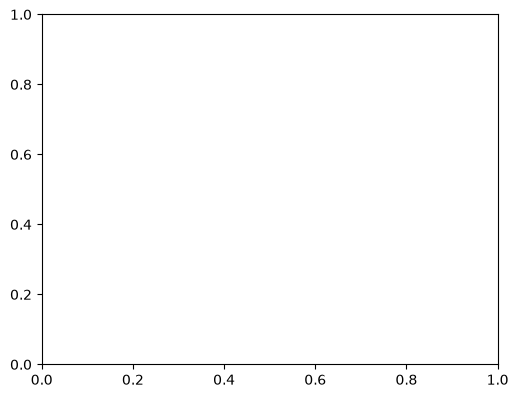

In [10]:
plotMPPs_wifi(t1=tag1, t2=tag2)

Begin reading
Starting MPP
Reading response
Got 483 readings.
Begin reading
Starting MPP
Reading response
Got 481 readings.
Begin reading
Starting MPP
Reading response
Got 486 readings.
Begin reading
Starting MPP
Reading response
Got 484 readings.
Begin reading
Starting MPP
Reading response
Got 479 readings.


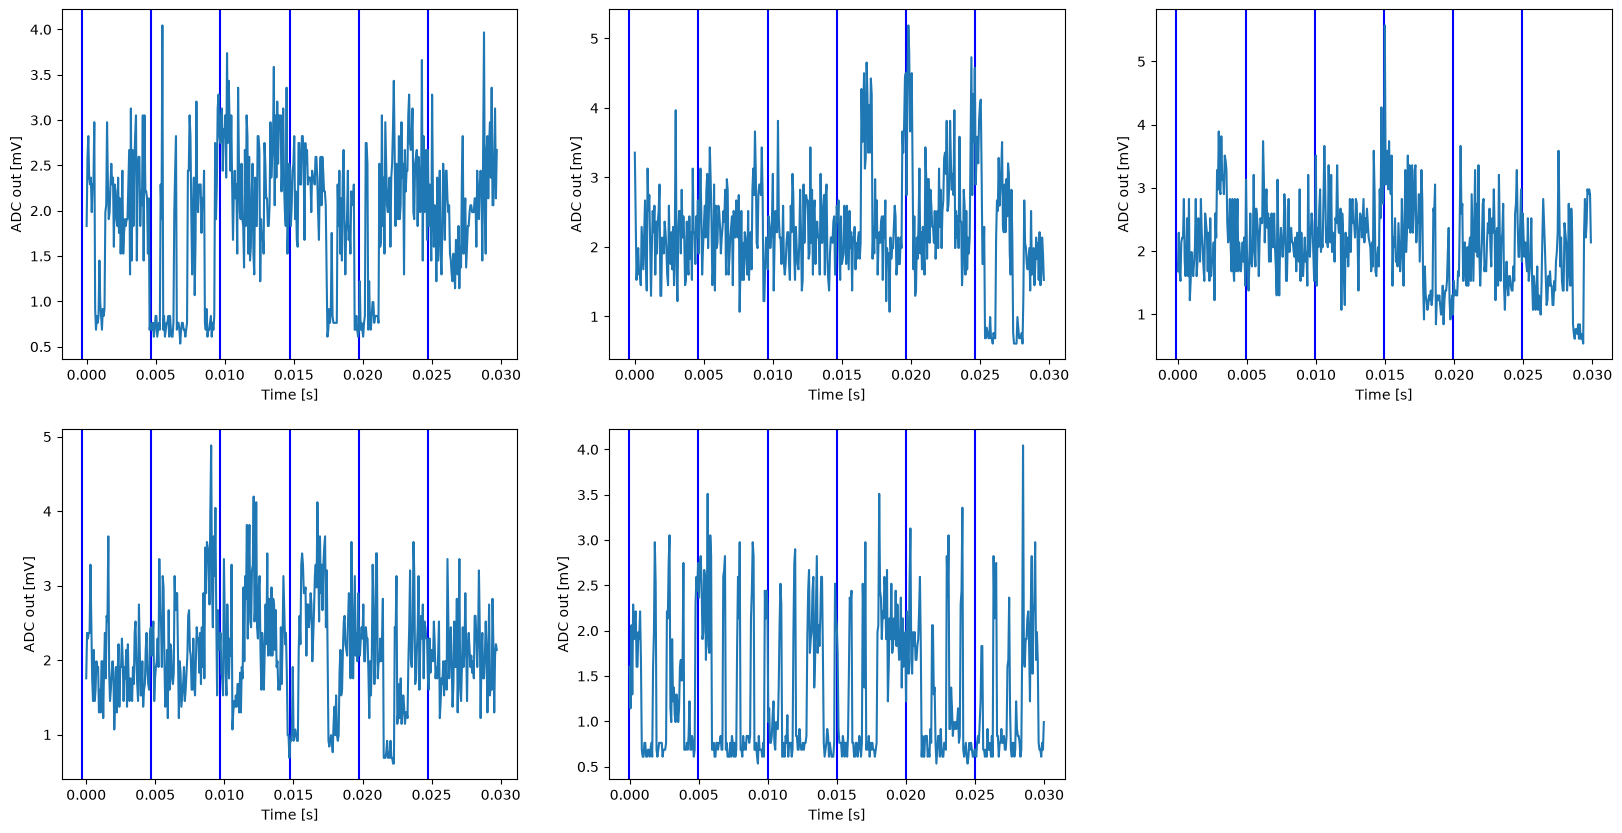

In [ ]:
plotMPPs(t1=tag2, t2=tag1)


In [ ]:
len

<function len(obj, /)>